# Data Quality – Missing Values
**Course:** Data & Analytics | Prof. Dr. Sonja Schneider  
**Institution:** Technische Hochschule Nürnberg Georg Simon Ohm  

**Contributors:**
- Danny Schönhals
- Athithya Mariyanayagam

## Dataset
**Autonomous Vehicle Survey of Bicyclists and Pedestrians in Pittsburgh (2019)**

Load the survey data for 2019 and inspect its structure before proceeding with the tasks.

In [17]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.experimental import enable_iterative_imputer  # must come before IterativeImputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder

%matplotlib inline

In [18]:
# Load the 2019 survey data
df_av = pd.read_csv("data/av_survey_data/avsurvey2019data.csv", encoding="latin-1")
print(f"Shape: {df_av.shape}")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
df_av.head()


Shape: (795, 23)


,RespondentID,StartDate,EndDate,FamiliarityNews,FamiliarityTech,SharedCyclist,SharedPedestrian,SafeAv,SafeHuman,AvImpact,ProvingGround,Speed25Mph,TwoEmployeesAv,SchoolZoneManual,ShareTripData,SharePerformanceData,ReportSafetyIncident,ArizonaCrash,ZipCode,BikePghMember,AutoOwner,SmartphoneOwner,Age
0,10505419886,2/2/2019,2/2/2019,To a moderate extent,Somewhat familiar,Yes,Yes,4.0,2.0,Significantly Better,Approve,No,Not sure,No,Not sure,Yes,Yes,No change,15212,No,Yes,Yes,25-34
1,10505138734,2/2/2019,2/2/2019,To a moderate extent,Somewhat familiar,Yes,No,5.0,4.0,Significantly Better,Neutral,No,No,No,No,Yes,Not sure,No change,15232,Not sure,Yes,Yes,25-34
2,10504803283,2/1/2019,2/1/2019,To a moderate extent,Somewhat familiar,Yes,Yes,1.0,4.0,Significantly Worse,Disapprove,Not sure,Yes,No,No,No,Not sure,Significantly more negative opinion,NaN,No,No,No,NaN
3,10504337177,2/1/2019,2/1/2019,To a moderate extent,Extremely familiar,Yes,Yes,2.0,3.0,Slightly Worse,Disapprove,Yes,Yes,Yes,No,Yes,Yes,No change,15136,No,No,Yes,55-64
4,10504261546,2/1/2019,2/1/2019,To a moderate extent,Mostly familiar,Yes,No,5.0,3.0,Slightly Better,Neutral,No,No,Not sure,Yes,Yes,No,No change,15201,Yes,No,Yes,35-44


In [19]:
df_av.describe

<bound method NDFrame.describe of      RespondentID  StartDate    EndDate       FamiliarityNews  \
0     10505419886   2/2/2019   2/2/2019  To a moderate extent   
1     10505138734   2/2/2019   2/2/2019  To a moderate extent   
2     10504803283   2/1/2019   2/1/2019  To a moderate extent   
3     10504337177   2/1/2019   2/1/2019  To a moderate extent   
4     10504261546   2/1/2019   2/1/2019  To a moderate extent   
..            ...        ...        ...                   ...   
790   10470569905  1/16/2019  1/16/2019  To a moderate extent   
791   10470569171  1/16/2019  1/16/2019  To a moderate extent   
792   10470532863  1/16/2019  1/16/2019  To a moderate extent   
793   10470438828  1/16/2019  1/16/2019        To some extent   
794   10468563638  1/15/2019  1/15/2019     To a large extent   

        FamiliarityTech SharedCyclist SharedPedestrian  SafeAv  SafeHuman  \
0     Somewhat familiar           Yes              Yes     4.0        2.0   
1     Somewhat familiar        

In [20]:
df_av.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 795 entries, 0 to 794
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   RespondentID          795 non-null    int64  
 1   StartDate             795 non-null    object 
 2   EndDate               795 non-null    object 
 3   FamiliarityNews       794 non-null    object 
 4   FamiliarityTech       794 non-null    object 
 5   SharedCyclist         792 non-null    object 
 6   SharedPedestrian      793 non-null    object 
 7   SafeAv                787 non-null    float64
 8   SafeHuman             792 non-null    float64
 9   AvImpact              788 non-null    object 
 10  ProvingGround         792 non-null    object 
 11  Speed25Mph            792 non-null    object 
 12  TwoEmployeesAv        792 non-null    object 
 13  SchoolZoneManual      793 non-null    object 
 14  ShareTripData         793 non-null    object 
 15  SharePerformanceData  7

In [21]:
from scipy import stats

# Missing counts per column
missing = df_av.isnull().sum()
missing_pct = (missing / len(df_av) * 100).round(1)
miss_summary = pd.DataFrame({'n_missing': missing, 'pct_missing': missing_pct})
miss_summary = miss_summary[miss_summary['n_missing'] > 0].sort_values('n_missing', ascending=False)
miss_summary

,n_missing,pct_missing
ZipCode,32,4.0
SafeAv,8,1.0
BikePghMember,8,1.0
AvImpact,7,0.9
Age,7,0.9
SharePerformanceData,4,0.5
SmartphoneOwner,4,0.5
SharedCyclist,3,0.4
ProvingGround,3,0.4
ArizonaCrash,3,0.4


### Visualisations 1a)

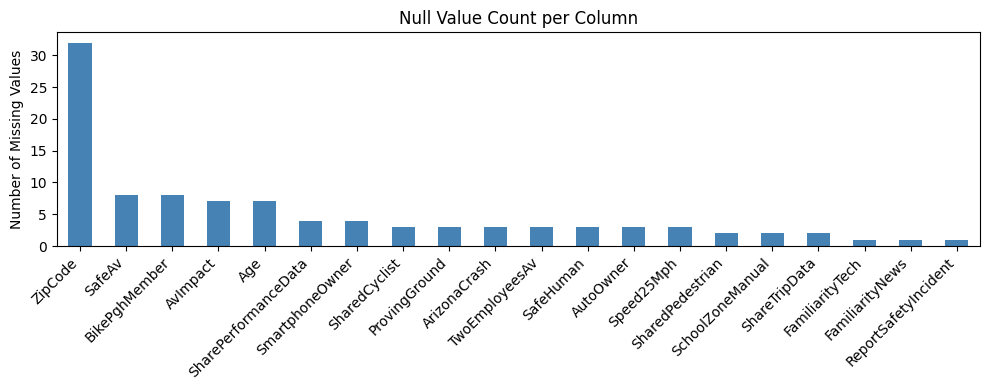

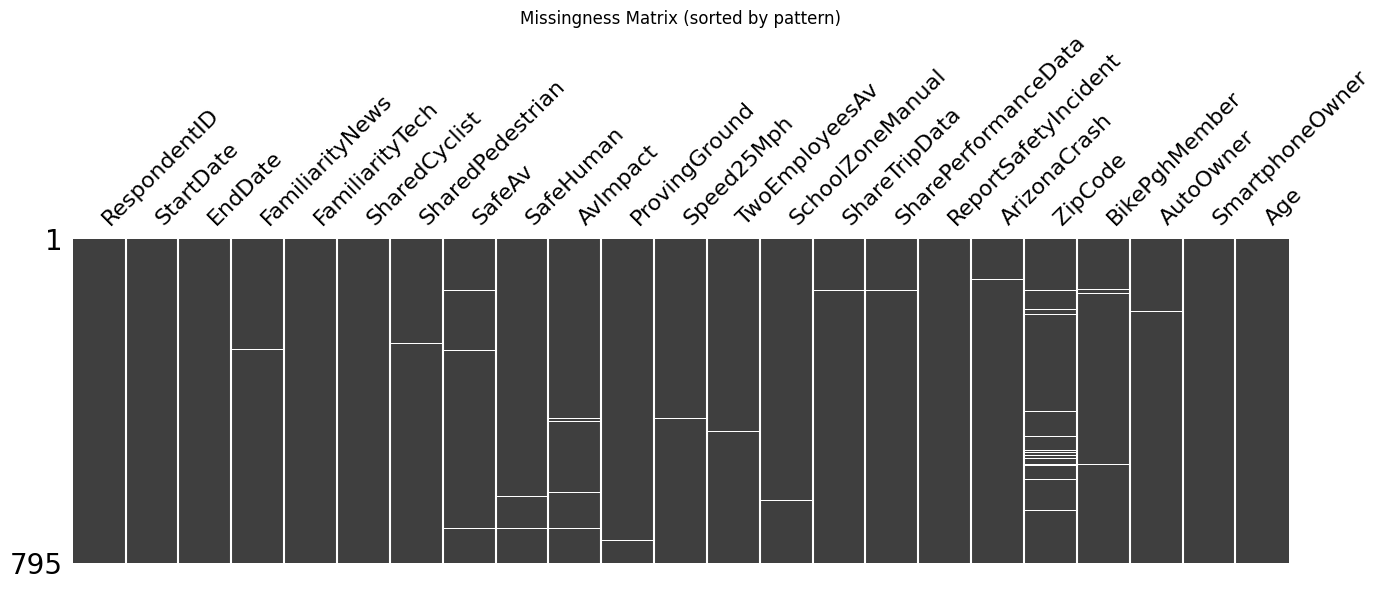

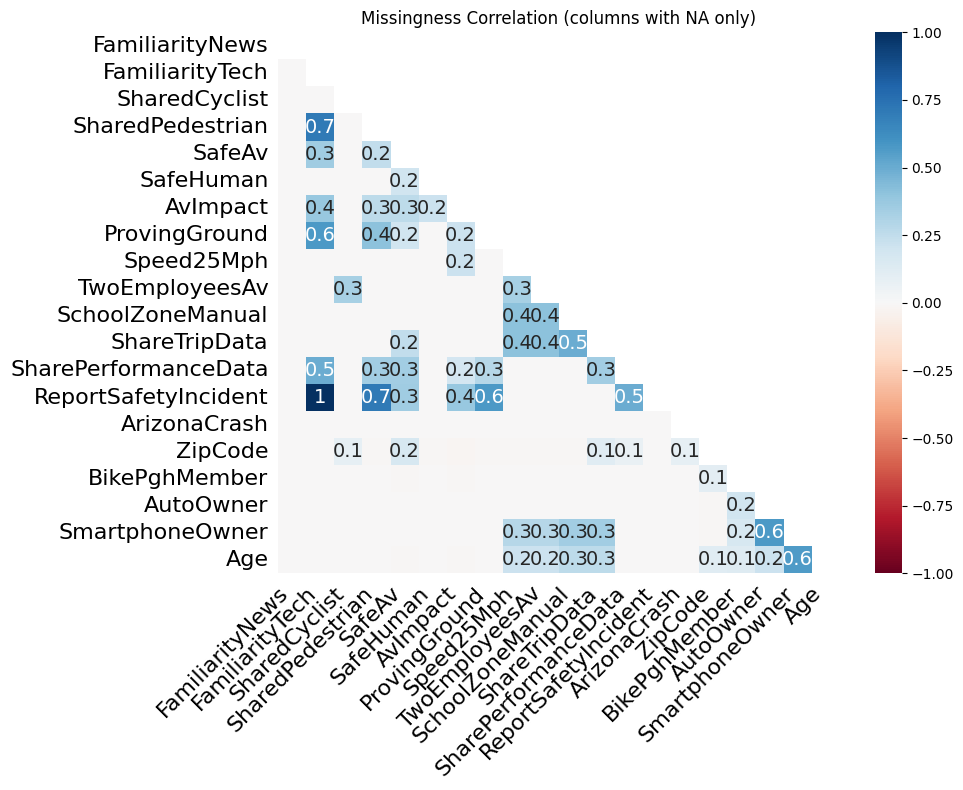

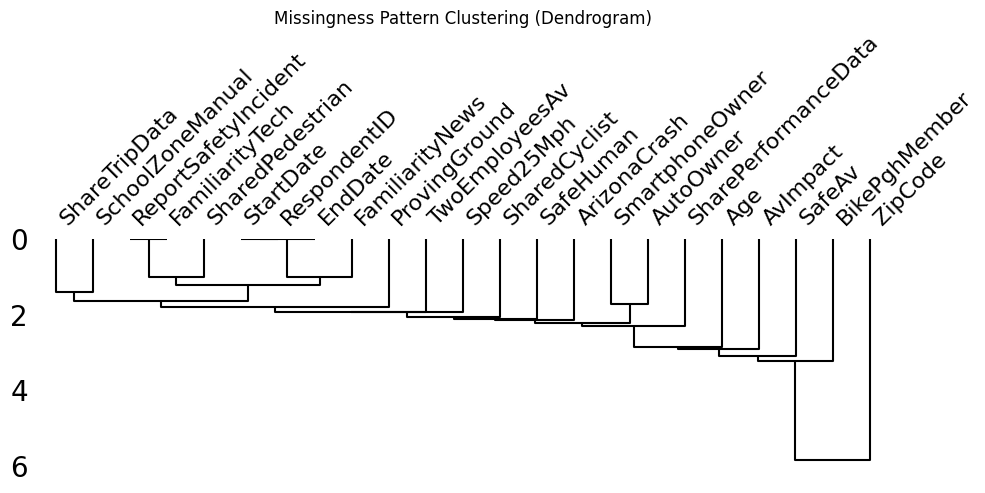

In [22]:
cols_with_na = df_av.columns[df_av.isnull().any()].tolist()

miss_summary['n_missing'].plot(kind='bar', figsize=(10, 4), color='steelblue')
plt.title('Null Value Count per Column')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

msno.matrix(df_av.sort_values(by=df_av.columns.tolist()), figsize=(14, 6), sparkline=False)
plt.title('Missingness Matrix (sorted by pattern)')
plt.tight_layout()
plt.show()

msno.heatmap(df_av[cols_with_na], figsize=(10, 8))
plt.title('Missingness Correlation (columns with NA only)')
plt.tight_layout()
plt.show()

msno.dendrogram(df_av, figsize=(10, 5))
plt.title('Missingness Pattern Clustering (Dendrogram)')
plt.tight_layout()
plt.show()

*Your interpretation here.*

---
## Task 2 – Is Missingness in `ZipCode` Related to Respondent Characteristics?

Examine whether the likelihood of `ZipCode` being missing depends on:
- **Age** of the respondent
- **Car ownership** (`AutoOwner`)
- **Smartphone ownership**

Use statistical tests (e.g. chi-square, t-test, logistic regression, or point-biserial correlation) and/or visualizations to support your analysis.

**Discuss the implications:** If missingness is related to one of these variables, what does that mean for the missingness mechanism (MCAR / MAR / MNAR)? How would this affect the validity of downstream analyses?

Age: χ²(6) = 7.474, p = 0.2792 
AutoOwner: χ²(1) = 0.324, p = 0.5694 
SmartphoneOwner: χ²(1) = 1.343, p = 0.2466 



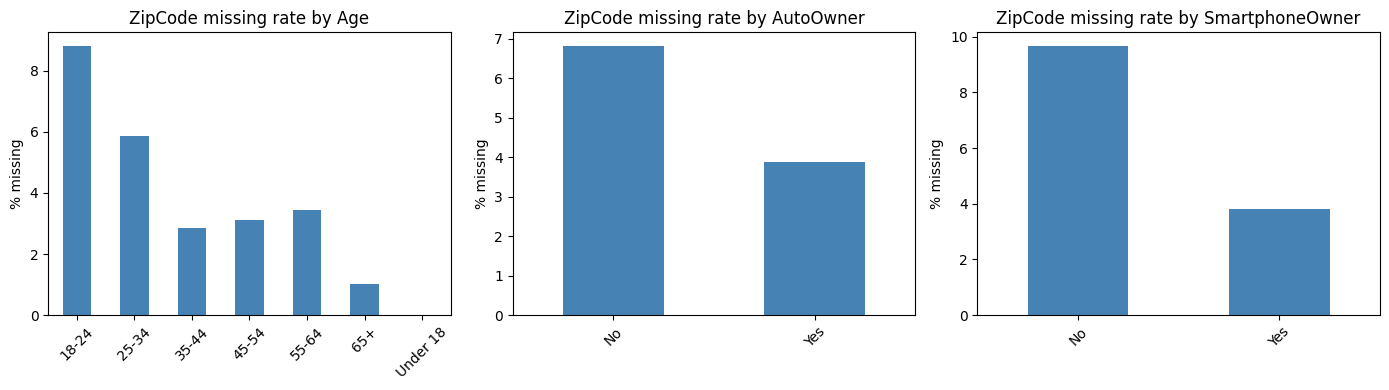

In [23]:
from scipy.stats import chi2_contingency

# Binary missingness indicator for ZipCode
df_av['ZipCode_missing'] = df_av['ZipCode'].isnull().astype(int)

# Chi-square test for each variable
for var in ['Age', 'AutoOwner', 'SmartphoneOwner']:
    subset = df_av[[var, 'ZipCode_missing']].dropna()
    ct = pd.crosstab(subset[var], subset['ZipCode_missing'])
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"{var}: χ²({dof}) = {chi2:.3f}, p = {p:.4f} {'*significant*' if p < 0.05 else ''}")

print()

# Visualise missing rate per category
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, var in zip(axes, ['Age', 'AutoOwner', 'SmartphoneOwner']):
    rate = df_av.groupby(var)['ZipCode_missing'].mean() * 100
    rate.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'ZipCode missing rate by {var}')
    ax.set_ylabel('% missing')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:**

None of the three variables show a significant relationship with ZipCode missingness (Age: p = 0.28, AutoOwner: p = 0.57, SmartphoneOwner: p = 0.25). This suggests the data is **MCAR**  the probability of ZipCode being missing does not depend on observed respondent characteristics. Analyses using only complete ZipCode records are therefore unlikely to introduce systematic bias.

---
## Task 3 – Compare Strategies for Handling Missing Data

Apply and compare four different approaches for handling missing values. After each approach, compute and compare **descriptive statistics and correlations** for the variables:
- `SafeAv`
- `BikePghMember`
- `AvImpact`
- `Age`

In [24]:
category_orders = {
    'AvImpact': ['Significantly Worse', 'Slightly Worse', 'No effect', 'Slightly Better', 'Significantly Better'],
    'Age':      ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
}

### 3a – Complete Case Analysis (List-wise Deletion)

Drop all rows that contain at least one missing value. Compute descriptive statistics and correlations on the remaining data.

In [25]:
focus_cols = ['SafeAv', 'BikePghMember', 'AvImpact', 'Age']

enc_map = {
    'BikePghMember': {'No': 0, 'Not sure': 1, 'Yes': 2},
    'AvImpact':      {v: i for i, v in enumerate(category_orders['AvImpact'])},
    'Age':           {v: i for i, v in enumerate(category_orders['Age'])}
}

df_complete = df_av[focus_cols].dropna()
print(f'Rows remaining: {len(df_complete)} / {len(df_av)} ({len(df_av)-len(df_complete)} dropped)')

display(df_complete.describe(include='all'))

df_enc = df_complete.copy()
for col, mapping in enc_map.items():
    df_enc[col] = df_enc[col].map(mapping)

print('Correlation Matrix (listwise):')
display(df_enc.corr(method='spearman').round(3))

Rows remaining: 768 / 795 (27 dropped)


,SafeAv,BikePghMember,AvImpact,Age
count,768.000000,768,768,768
unique,NaN,3,5,7
top,NaN,Yes,Significantly Better,25-34
freq,NaN,378,302,201
mean,3.691406,NaN,NaN,NaN
std,1.188747,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3.000000,NaN,NaN,NaN
50%,4.000000,NaN,NaN,NaN
75%,5.000000,NaN,NaN,NaN


Correlation Matrix (listwise):


,SafeAv,BikePghMember,AvImpact,Age
SafeAv,1.000,0.067,0.650,-0.081
BikePghMember,0.067,1.000,0.040,0.116
AvImpact,0.650,0.040,1.000,-0.149
Age,-0.081,0.116,-0.149,1.000


### 3b – Available Case Analysis (Pair-wise Deletion)

Use all available observations for each pairwise computation (e.g. correlations). Do not drop full rows — instead compute each statistic using only the non-missing values for the relevant variable(s).

In [26]:
# Descriptive stats use all non-missing values per variable
display(df_av[focus_cols].describe(include='all'))

# Encode for correlation
df_av_enc = df_av[focus_cols].copy()
for col, mapping in enc_map.items():
    df_av_enc[col] = df_av_enc[col].map(mapping)

print("Correlation Matrix (pairwise):")
display(df_av_enc.corr(method='spearman', min_periods=1).round(3))

,SafeAv,BikePghMember,AvImpact,Age
count,787.000000,787,788,788
unique,NaN,3,5,7
top,NaN,Yes,Significantly Better,25-34
freq,NaN,387,303,205
mean,3.679797,NaN,NaN,NaN
std,1.192272,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3.000000,NaN,NaN,NaN
50%,4.000000,NaN,NaN,NaN
75%,5.000000,NaN,NaN,NaN


Correlation Matrix (pairwise):


,SafeAv,BikePghMember,AvImpact,Age
SafeAv,1.000,0.073,0.653,-0.085
BikePghMember,0.073,1.000,0.056,0.107
AvImpact,0.653,0.056,1.000,-0.158
Age,-0.085,0.107,-0.158,1.000


**3a – Complete Case Analysis:**  
768 out of 795 rows remain after dropping all rows with at least one missing value (27 rows dropped).
SafeAv and AvImpact are strongly correlated (ρ = 0.65), meaning respondents who expect AVs to have a
bigger positive impact also rate them as safer.
Age shows weak negative correlations with SafeAv (ρ = -0.08) and AvImpact (ρ = -0.15),
suggesting older respondents are slightly more skeptical.
BikePgh membership has negligible correlations with all other variables.

**3b – Available Case Analysis (Pairwise Deletion):**  
Using all non-missing pairs retains up to 795 observations per variable.
The correlations remain nearly identical to complete case analysis (SafeAv – AvImpact: ρ = 0.65 in both).
The small number of missing values (7–8 per column) means both approaches yield the same conclusions.

### 3c – Single Imputation

Replace missing values with a single imputed value (e.g. mode for categorical, mean/median for numeric). Use `sklearn.impute.SimpleImputer` for efficiency. Justify your choice of imputation strategy.

In [27]:
from sklearn.impute import SimpleImputer

df_single = df_av[focus_cols].copy()

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

df_single[['SafeAv']] = num_imputer.fit_transform(df_single[['SafeAv']])
df_single[['BikePghMember', 'AvImpact', 'Age']] = cat_imputer.fit_transform(
    df_single[['BikePghMember', 'AvImpact', 'Age']]
)

print(f'Missing values after imputation: {df_single.isnull().sum().sum()}')
print(f'SafeAv imputed with mean:        {num_imputer.statistics_[0]:.3f}')
print(f'BikePghMember imputed with mode: {cat_imputer.statistics_[0]}')
print(f'AvImpact      imputed with mode: {cat_imputer.statistics_[1]}')
print(f'Age           imputed with mode: {cat_imputer.statistics_[2]}')

df_single_enc = df_single.copy()
for col, mapping in enc_map.items():
    df_single_enc[col] = df_single_enc[col].map(mapping)

print('\nDescriptive statistics (single imputation):')
display(df_single_enc.describe().round(3))

print('\nCorrelation Matrix (single imputation):')
display(df_single_enc.corr(method='spearman').round(3))

Missing values after imputation: 0
SafeAv imputed with mean:        3.680
BikePghMember imputed with mode: Yes
AvImpact      imputed with mode: Significantly Better
Age           imputed with mode: 25-34

Descriptive statistics (single imputation):


,SafeAv,BikePghMember,AvImpact,Age
count,795.000,795.000,795.000,795.000
mean,3.680,1.083,2.926,3.541
std,1.186,0.951,1.156,1.470
min,1.000,0.000,0.000,0.000
25%,3.000,0.000,2.000,2.000
50%,4.000,1.000,3.000,3.000
75%,5.000,2.000,4.000,5.000
max,5.000,2.000,4.000,6.000



Correlation Matrix (single imputation):


,SafeAv,BikePghMember,AvImpact,Age
SafeAv,1.000,0.072,0.644,-0.079
BikePghMember,0.072,1.000,0.057,0.108
AvImpact,0.644,0.057,1.000,-0.146
Age,-0.079,0.108,-0.146,1.000


**3c – Single Imputation:**  
SafeAv was imputed with its mean (3.680), while BikePghMember, AvImpact, and Age were imputed
with their mode ("Yes", "Significantly Better", "25-34"). All 795 rows are now complete.
The SafeAv – AvImpact correlation stays at ρ = 0.64, nearly identical to the complete case result.
Single imputation can underestimate variance because all missing observations are pulled to the same fixed value,
which may slightly dampen correlations.

### 3d – Multiple Imputation

Use `sklearn.experimental.enable_iterative_imputer` and `IterativeImputer` with a classifier that handles categorical data (e.g. `RandomForestClassifier` or `DecisionTreeClassifier`).

Encode ordinal variables using `OrdinalEncoder` with the `categories` parameter from the `category_orders` dictionary defined above.

In [28]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder

cat_cols = ['BikePghMember', 'AvImpact', 'Age']
df_multi = df_av[focus_cols].copy()

oe = OrdinalEncoder(
    categories=[['No', 'Not sure', 'Yes'], category_orders['AvImpact'], category_orders['Age']],
    handle_unknown='use_encoded_value', unknown_value=np.nan
)
df_multi[cat_cols] = oe.fit_transform(df_multi[cat_cols])

imputer = IterativeImputer(random_state=42, max_iter=10)
arr_imputed = imputer.fit_transform(df_multi)
df_multi_imp = pd.DataFrame(arr_imputed, columns=focus_cols)

for j, col in enumerate(cat_cols):
    n = len(oe.categories_[j])
    df_multi_imp[col] = df_multi_imp[col].round().astype(int).clip(0, n - 1)

print(f'Missing values after imputation: {df_multi_imp.isnull().sum().sum()}')

print('\nDescriptive statistics (multiple imputation):')
display(df_multi_imp.describe().round(3))

print('\nCorrelation Matrix (multiple imputation):')
display(df_multi_imp.corr(method='spearman').round(3))

Missing values after imputation: 0

Descriptive statistics (multiple imputation):


,SafeAv,BikePghMember,AvImpact,Age
count,795.000,795.000,795.000,795.000
mean,3.673,1.073,2.916,3.558
std,1.191,0.947,1.155,1.463
min,1.000,0.000,0.000,0.000
25%,3.000,0.000,2.000,2.000
50%,4.000,1.000,3.000,3.000
75%,5.000,2.000,4.000,5.000
max,5.000,2.000,4.000,6.000



Correlation Matrix (multiple imputation):


,SafeAv,BikePghMember,AvImpact,Age
SafeAv,1.000,0.081,0.659,-0.093
BikePghMember,0.081,1.000,0.058,0.104
AvImpact,0.659,0.058,1.000,-0.159
Age,-0.093,0.104,-0.159,1.000


**3d – Multiple Imputation:**  
IterativeImputer models each variable from the others iteratively (10 passes, random_state=42).
The SafeAv – AvImpact correlation increases slightly to ρ = 0.66, compared to 0.65 (listwise) and 0.64 (single imputation).
Age – AvImpact strengthens to ρ = -0.16 and Age – SafeAv to ρ = -0.09.
Multiple imputation uses the relationships between variables to estimate plausible values,
which better preserves the covariance structure than mean/mode substitution.

---
## Summary Comparison

Bring together the descriptive statistics and correlation results from all four approaches in a clear comparison table or visualization. Discuss:
- Which approach best preserves the original data distribution?
- Which approach introduces the most distortion?
- Which approach would you recommend for this dataset and why?

In [29]:
print('SafeAv - AvImpact Spearman correlation across all four strategies:')
summary = {
    '3a Complete Case':       df_enc.corr(method='spearman').loc['SafeAv', 'AvImpact'],
    '3b Pairwise Deletion':   df_av_enc.corr(method='spearman', min_periods=1).loc['SafeAv', 'AvImpact'],
    '3c Single Imputation':   df_single_enc.corr(method='spearman').loc['SafeAv', 'AvImpact'],
    '3d Multiple Imputation': df_multi_imp.corr(method='spearman').loc['SafeAv', 'AvImpact'],
}
for method, rho in summary.items():
    print(f'  {method:30s}: rho = {rho:.3f}')

print('\nSample sizes used:')
print(f'  3a Complete Case:        {len(df_enc)} rows')
print(f'  3b Pairwise Deletion:    up to {len(df_av_enc)} rows')
print(f'  3c Single Imputation:    {len(df_single_enc)} rows')
print(f'  3d Multiple Imputation:  {len(df_multi_imp)} rows')

SafeAv - AvImpact Spearman correlation across all four strategies:
  3a Complete Case              : rho = 0.650
  3b Pairwise Deletion          : rho = 0.653
  3c Single Imputation          : rho = 0.644
  3d Multiple Imputation        : rho = 0.659

Sample sizes used:
  3a Complete Case:        768 rows
  3b Pairwise Deletion:    up to 795 rows
  3c Single Imputation:    795 rows
  3d Multiple Imputation:  795 rows


**Summary:**  
All four strategies produce a very similar SafeAv – AvImpact correlation (ρ ≈ 0.64–0.66),
which is the strongest relationship in the dataset.
The low number of missing values (7–8 per column out of 795, < 1.1%) means the choice of strategy
has little practical impact here.
Complete case and pairwise deletion give essentially the same result.
Single imputation slightly reduces correlations toward zero by anchoring all missing values to one fixed value.
Multiple imputation produces the most theoretically sound estimates but is computationally heavier —
in this dataset, the differences are negligible.